In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/afsana22/home-credit-default-risk-data/sample_submission.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/bureau_balance.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/POS_CASH_balance.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/application_train.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/HomeCredit_columns_description.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/application_test.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/previous_application.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/credit_card_balance.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/installments_payments.csv
/kaggle/input/datasets/afsana22/home-credit-default-risk-data/bureau.csv


## ## Home Credit Default Risk Prediction

## Project Objective

The objective of this project is to predict whether a customer is likely to default on a loan using historical credit and financial data. By leveraging machine learning techniques, the project aims to support financial institutions in making informed lending decisions, reducing credit risk, and improving overall operational efficiency.

# PHASE 1

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve

## LOADING DATASETS

In [2]:
DATA_PATH = "/kaggle/input/datasets/afsana22/home-credit-default-risk-data/"

train = pd.read_csv(DATA_PATH + "application_train.csv")
bureau = pd.read_csv(DATA_PATH + "bureau.csv")
bureau_balance = pd.read_csv(DATA_PATH + "bureau_balance.csv")
prev_app = pd.read_csv(DATA_PATH + "previous_application.csv")
installments = pd.read_csv(DATA_PATH + "installments_payments.csv")
cc_balance = pd.read_csv(DATA_PATH + "credit_card_balance.csv")
pos_cash = pd.read_csv(DATA_PATH + "POS_CASH_balance.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


## Basic Info Checking for Datasets

In [4]:
# existing dictionary of dataframes
dfs = {
    'Application Train': train,
    'Bureau': bureau,
    'Bureau Balance': bureau_balance,
    'Previous App': prev_app,
    'Installments': installments,
    'CC Balance': cc_balance,
    'POS Cash': pos_cash
}

# Loop to see Head and Missing Values for all
for name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"TABLE: {name}")
    print(f"{'='*50}")
    
    # 1. Printing Shape
    print(f"Shape: {df.shape}")
    
    # 2. Calculating Total Missing Values
    total_missing = df.isnull().sum().sum()
    cols_with_missing = (df.isnull().sum() > 0).sum()
    
    print(f"Total Missing Values: {total_missing}")
    print(f"Number of Columns with Missing Values: {cols_with_missing}")
    
    # 3. Showing first 6 rows
    print("\nFirst 6 rows:")
    display(df.head(6)) 
    print("\n")


TABLE: Application Train
Shape: (307511, 122)
Total Missing Values: 9152465
Number of Columns with Missing Values: 67

First 6 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0





TABLE: Bureau
Shape: (1716428, 17)
Total Missing Values: 3939947
Number of Columns with Missing Values: 7

First 6 rows:


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.00,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.00,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN
5,215354,5714467,Active,currency 1,-273,0,27460.0,NaN,0.0,0,180000.0,71017.38,108982.62,0.0,Credit card,-31,NaN





TABLE: Bureau Balance
Shape: (27299925, 3)
Total Missing Values: 0
Number of Columns with Missing Values: 0

First 6 rows:


...

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585
5,1137312,164489,1.0,12,-1384.0,-1417.0,5970.375,5970.375





TABLE: CC Balance
Shape: (3840312, 23)
Total Missing Values: 5877356
Number of Columns with Missing Values: 9

First 6 rows:


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0
5,2646502,380010,-7,82903.815,270000,0.0,0.0,0.0,0.0,4449.105,...,82773.315,82773.315,0.0,0,0.0,0.0,2.0,Active,7,0





TABLE: POS Cash
Shape: (10001358, 8)
Total Missing Values: 52158
Number of Columns with Missing Values: 2

First 6 rows:


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
5,2207092,342166,-32,12.0,12.0,Active,0,0


## Handling Missing Values

In [5]:
def clean_dataset(df):
    df_cleaned = df.copy()
    
    # Identifying Numerical and Categorical columns
    num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = df_cleaned.select_dtypes(include=['object']).columns
    
    # 1. Handling Numerical Missing Values
    for col in num_cols:
        if df_cleaned[col].isnull().sum() > 0:
            # Adding indicator column: 1 if missing, 0 if not
            df_cleaned[f'{col}_was_missing'] = df_cleaned[col].isnull().astype(int)
            # Filling with Median
            df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())
            
    # 2. Handling Categorical Missing Values
    for col in cat_cols:
        if df_cleaned[col].isnull().sum() > 0:
            # Adding indicator column: 1 if missing, 0 if not
            df_cleaned[f'{col}_was_missing'] = df_cleaned[col].isnull().astype(int)
            # Filling with "Unknown"
            df_cleaned[col] = df_cleaned[col].fillna("Unknown")
            
    return df_cleaned

print("Cleaning function defined successfully!")

Cleaning function defined successfully!


In [6]:
# Dictionary containing original dataframes
dfs = {
    'Application Train': train,
    'Bureau': bureau,
    'Bureau Balance': bureau_balance,
    'Previous App': prev_app,
    'Installments': installments,
    'CC Balance': cc_balance,
    'POS Cash': pos_cash
}

# New dictionary to store the cleaned versions
cleaned_dfs = {}

for name, df in dfs.items():
    print(f"Cleaning {name}...")
    cleaned_dfs[name] = clean_dataset(df)

print("\nAll tables have been cleaned!")

Cleaning Application Train...


/tmp/ipykernel_58/2538273933.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cleaned[f'{col}_was_missing'] = df_cleaned[col].isnull().astype(int)
/tmp/ipykernel_58/2538273933.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cleaned[f'{col}_was_missing'] = df_cleaned[col].isnull().astype(int)
/tmp/ipykernel_58/2538273933.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

Cleaning Bureau...
Cleaning Bureau Balance...
Cleaning Previous App...
Cleaning Installments...
Cleaning CC Balance...
Cleaning POS Cash...

All tables have been cleaned!


## Datasets Info After Missing Value Handeling

In [7]:
for name, df in cleaned_dfs.items():
    print(f"--- {name} ---")
    print(f"New Shape: {df.shape}") # You will see the shape increased because of indicator columns
    print(f"Total Missing Values: {df.isnull().sum().sum()}")
    print("-" * 30)

--- Application Train ---
New Shape: (307511, 189)
Total Missing Values: 0
------------------------------
--- Bureau ---
New Shape: (1716428, 24)
Total Missing Values: 0
------------------------------
--- Bureau Balance ---
New Shape: (27299925, 3)
Total Missing Values: 0
------------------------------
--- Previous App ---
New Shape: (1670214, 53)
Total Missing Values: 0
------------------------------
--- Installments ---
New Shape: (13605401, 10)
Total Missing Values: 0
------------------------------
--- CC Balance ---
New Shape: (3840312, 32)
Total Missing Values: 0
------------------------------
--- POS Cash ---
New Shape: (10001358, 10)
Total Missing Values: 0
------------------------------


## Extracting Cleaned Dataframes

In [8]:
# Extracting from cleaned_dfs dictionary
train_df = cleaned_dfs['Application Train']
bureau_df = cleaned_dfs['Bureau']
bureau_bal_df = cleaned_dfs['Bureau Balance']
prev_app_df = cleaned_dfs['Previous App']
inst_df = cleaned_dfs['Installments']
cc_bal_df = cleaned_dfs['CC Balance']
pos_cash_df = cleaned_dfs['POS Cash']

print("Dataframes extracted and ready for engineering!")

Dataframes extracted and ready for engineering!


## Feature Engineering

In [9]:
# 1. Bureau Features
# Goal: bureau_loan_count, active_loan_count, closed_loan_count, mean_credit_sum, max_credit_sum
bureau_agg = bureau_df.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count', 
    'CREDIT_ACTIVE': lambda x: (x == 'Active').sum(),
    'AMT_CREDIT_SUM': ['mean', 'max']
})
bureau_agg.columns = ['bureau_loan_count', 'active_loan_count', 'mean_credit_sum', 'max_credit_sum']
bureau_agg['closed_loan_count'] = bureau_df.groupby('SK_ID_CURR')['CREDIT_ACTIVE'].apply(lambda x: (x == 'Closed').sum())

# 2. Previous Application Features
# Goal: previous_application_count, approval_rate, rejection_rate, average_previous_credit
prev_agg = prev_app_df.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': 'mean',
    'NAME_CONTRACT_STATUS': [lambda x: (x == 'Approved').sum() / len(x), 
                             lambda x: (x == 'Refused').sum() / len(x)]
})
prev_agg.columns = ['previous_application_count', 'average_previous_credit', 'approval_rate', 'rejection_rate']

# 3. Installments Payment Aggregation
inst_agg = inst_df.groupby('SK_ID_CURR').agg({'AMT_PAYMENT': ['sum', 'mean']})
inst_agg.columns = ['total_installments_paid', 'avg_installment_payment']

# 4. Credit Card Balance Aggregation
cc_agg = cc_bal_df.groupby('SK_ID_CURR').agg({'AMT_BALANCE': ['mean', 'max']})
cc_agg.columns = ['avg_cc_balance', 'max_cc_balance']

# 5. POS Cash Aggregation (FIXED: Using SK_DPD instead of AMT_BALANCE)
# SK_DPD = Days Past Due. The higher the number, the riskier the customer.
pos_agg = pos_cash_df.groupby('SK_ID_CURR').agg({
    'SK_DPD': 'max', 
    'CNT_INSTALMENT': 'mean'
})
pos_agg.columns = ['max_pos_dpd', 'avg_pos_instalments']

# 6. Bureau Balance Aggregation (FIXED: Using STATUS)
# Since we only have STATUS, let's count how many times a customer had a 'C' (Closed) status
bb_agg = bureau_bal_df.groupby('SK_ID_BUREAU').agg({
    'STATUS': lambda x: (x == 'C').sum()
})
bb_agg.columns = ['closed_bureau_status_count']

print("Feature Engineering Corrected and Complete!")

Feature Engineering Corrected and Complete!


## Merging and Encoding

In [10]:
# Start with the main train table
master_df = train_df.copy()

# Merge all tables using 'left' join
master_df = master_df.merge(bureau_agg, on='SK_ID_CURR', how='left')
master_df = master_df.merge(prev_agg, on='SK_ID_CURR', how='left')
master_df = master_df.merge(inst_agg, on='SK_ID_CURR', how='left')
master_df = master_df.merge(cc_agg, on='SK_ID_CURR', how='left')
master_df = master_df.merge(pos_agg, on='SK_ID_CURR', how='left')

# Label Encoding for categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = master_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    master_df[col] = le.fit_transform(master_df[col].astype(str))

# Final check for any NaNs that were created during merging
master_df = master_df.fillna(0) 

print(f"Final Master Dataset Shape: {master_df.shape}")
display(master_df.head())

Final Master Dataset Shape: (307511, 204)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,previous_application_count,average_previous_credit,approval_rate,rejection_rate,total_installments_paid,avg_installment_payment,avg_cc_balance,max_cc_balance,max_pos_dpd,avg_pos_instalments
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,1.0,179055.00,1.000000,0.000000,219625.695,11559.247105,0.0,0.0,0.0,24.000000
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,3.0,435436.50,1.000000,0.000000,1618864.650,64754.586000,0.0,0.0,0.0,10.107143
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,1.0,24282.00,1.000000,0.000000,21288.465,7096.155000,0.0,0.0,0.0,3.750000
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,9.0,272203.26,0.555556,0.111111,1007153.415,62947.088438,0.0,0.0,0.0,12.000000
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,6.0,150530.25,1.000000,0.000000,806127.975,12214.060227,0.0,0.0,0.0,15.333333


## Save The Master Dataset For Deplyment

In [11]:
# ---------------------------
# 6. SAVE TO KAGGLE WORKING DIRECTORY
# ---------------------------
output_path = "/kaggle/working/final_master_dataset.csv"
master_df.to_csv(output_path, index=False)

print(f"Saved successfully at: {output_path}")

Saved successfully at: /kaggle/working/final_master_dataset.csv


In [15]:
import os
os.listdir("/kaggle/working/")

['final_master_dataset.csv', '.virtual_documents']

In [18]:
from IPython.display import display, FileLink

display(FileLink("/kaggle/working/final_master_dataset.csv"))

/kaggle/working/final_master_dataset.csv

## ##Business Perception

## Problem

Financial institutions face significant challenges in identifying customers who are likely to default on loans. Incorrect lending decisions can lead to financial losses, increased credit risk, and reduced profitability. Traditional manual assessment methods are often time-consuming and may fail to capture complex patterns within customer data.

## Steps Taken to Solve

- Collected and integrated data from multiple Home Credit datasets.
- Performed data cleaning and missing value handling.
- Applied feature engineering to create meaningful customer-level features.
- Encoded categorical variables and prepared the final modeling dataset.
- Trained and evaluated multiple machine learning models.
- Selected the best-performing model based on ROC-AUC score.
- Optimized the selected model and prepared it for deployment.

## Implementation (Technical)

- Data preprocessing using Pandas and NumPy.
- Missing value treatment using median imputation and categorical replacement.
- Feature engineering through aggregation of bureau, previous applications, installments, credit card, and POS cash records.
- Label encoding for categorical variables.
- Model training using Logistic Regression, Random Forest, XGBoost, and LightGBM.
- Model evaluation using ROC-AUC, Confusion Matrix, and Classification Report.
- Hyperparameter tuning and class imbalance handling for LightGBM.
- Deployment using FastAPI and containerization using Docker.

## Ways to Solve the Problem

- Rule-based credit scoring systems.
- Statistical approaches such as Logistic Regression.
- Machine Learning approaches such as Random Forest, XGBoost, and LightGBM.
- Deep Learning-based credit risk assessment models.
- Hybrid systems combining business rules with machine learning predictions.

In this project, machine learning-based credit risk prediction was selected due to its ability to capture complex relationships within customer data and provide higher predictive accuracy.

## Impact of the Project

- Reduces the risk of loan defaults by identifying high-risk applicants before loan approval.
- Improves the accuracy and consistency of credit risk assessment through data-driven decision making.
- Speeds up the loan evaluation process by automating customer risk prediction.
- Helps financial institutions minimize financial losses and maximize profitability.
- Enhances customer experience by enabling faster loan approval decisions.
- Provides a scalable solution through FastAPI and Docker deployment for real-world applications.

# Phase 2

## ## Model Explanations

## Logistic Regression

Logistic Regression is a simple and interpretable classification algorithm commonly used for binary classification problems. It serves as a baseline model for credit risk prediction and provides insights into the relationship between customer features and loan default probability.


## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is effective for handling large datasets and capturing non-linear relationships between variables.

## XGBoost

XGBoost is a gradient boosting algorithm designed for high predictive performance and efficiency. It sequentially builds decision trees to correct errors made by previous trees, making it highly effective for structured financial datasets.

## LightGBM

LightGBM is a gradient boosting framework optimized for speed and performance on large-scale tabular datasets. It efficiently handles high-dimensional data, missing values, and class imbalance, making it particularly suitable for credit risk prediction.


# Preparing Features and Target

In [19]:
# Define X (features) and y (target)
X = master_df.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = master_df['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (307511, 202)
Target shape: (307511,)


## Model Comparison & Ratio Variation

In [20]:
# Define the models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}

# Define the split ratios to test
split_ratios = [0.3, 0.2, 0.1] # 30%, 20%, 10% for validation
all_results = []

for ratio in split_ratios:
    print(f"\nTesting Split Ratio: {int((1-ratio)*100)}% Train / {int(ratio*100)}% Val")
    
    # Stratified split to maintain the imbalance ratio of Target 0 and 1
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=ratio, stratify=y, random_state=42)
    
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict probabilities for the positive class (Target=1)
        probs = model.predict_proba(X_val)[:, 1]
        
        # Calculate ROC-AUC Score
        auc_score = roc_auc_score(y_val, probs)
        
        all_results.append({
            'Split': f"{int((1-ratio)*100)}/{int(ratio*100)}",
            'Model': model_name,
            'ROC-AUC': auc_score
        })
        print(f"{model_name} AUC: {auc_score:.4f}")

# Convert results to a DataFrame for the report
results_df = pd.DataFrame(all_results)
# Pivot the table for a professional look
comparison_table = results_df.pivot(index='Model', columns='Split', values='ROC-AUC')
display(comparison_table)


Testing Split Ratio: 70% Train / 30% Val


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC: 0.6291
Random Forest AUC: 0.7489


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:48:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7606
[LightGBM] [Info] Number of positive: 17377, number of negative: 197880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.139953 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14053
[LightGBM] [Info] Number of data points in the train set: 215257, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432513
[LightGBM] [Info] Start training from score -2.432513
LightGBM AUC: 0.7701

Testing Split Ratio: 80% Train / 20% Val


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression AUC: 0.6293
Random Forest AUC: 0.7494


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:55:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC: 0.7644
[LightGBM] [Info] Number of positive: 22342, number of negative: 254417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.167163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14079
[LightGBM] [Info] Number of data points in the train set: 276759, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432506
[LightGBM] [Info] Start training from score -2.432506
LightGBM AUC: 0.7724


Split,70/30,80/20,90/10
Model,,,
LightGBM,0.770080,0.772592,0.772412
Logistic Regression,0.629060,0.631811,0.629259
Random Forest,0.748910,0.748210,0.749380
XGBoost,0.760648,0.765193,0.764443


## ##Model Performance Summary

Four machine learning models—Logistic Regression, Random Forest, XGBoost, and LightGBM—were evaluated for the task of credit default prediction. The models were compared using the ROC-AUC score, which is an appropriate evaluation metric for imbalanced classification problems as it measures the model’s ability to distinguish between defaulters and non-defaulters.

Experiments were conducted using multiple train-validation split ratios (70/30, 80/20, and 90/10) to assess model stability and robustness across different data distributions.

Among all models tested, LightGBM consistently achieved the highest ROC-AUC score (~0.77) across all split ratios. It also demonstrated stable performance with minimal variation, indicating strong generalization capability on unseen data. Gradient boosting models (LightGBM and XGBoost) significantly outperformed both Logistic Regression and Random Forest, highlighting the importance of capturing complex non-linear relationships in the dataset.

Based on both performance and stability, LightGBM was selected as the final model for deployment and further optimization.

## OPTIMIZATION: Addressing Class Imbalance for Higher Recall

Imbalance Ratio: 11.39
[LightGBM] [Info] Number of positive: 22342, number of negative: 254417
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.207726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14079
[LightGBM] [Info] Number of data points in the train set: 276759, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432506
[LightGBM] [Info] Start training from score -2.432506


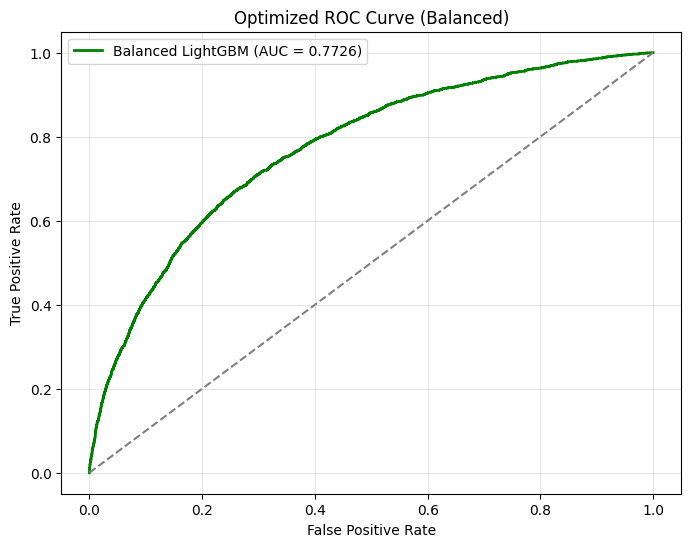

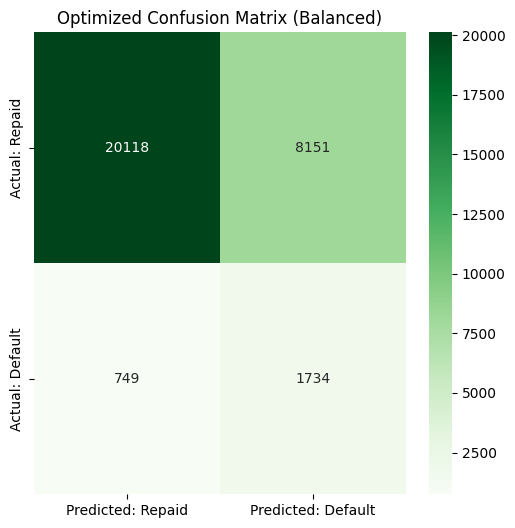


--- Optimized Final Performance Report ---
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     28269
           1       0.18      0.70      0.28      2483

    accuracy                           0.71     30752
   macro avg       0.57      0.71      0.55     30752
weighted avg       0.90      0.71      0.78     30752



In [21]:

# 1. Calculate the imbalance ratio (Negatives / Positives)
# This tells the model to treat 1 default as being as important as X repaid loans
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance Ratio: {ratio:.2f}")

# 2. Re-train the LightGBM model using the scale_pos_weight parameter
# This is the 'Pro Fix' to increase the recall for the Default class
final_model_balanced = LGBMClassifier(scale_pos_weight=ratio)
final_model_balanced.fit(X_train, y_train)

# 3. Get new Predictions
probs_balanced = final_model_balanced.predict_proba(X_val)[:, 1]
preds_balanced = final_model_balanced.predict(X_val)

# --- VISUAL 1: NEW ROC CURVE ---
fpr_b, tpr_b, _ = roc_curve(y_val, probs_balanced)
plt.figure(figsize=(8, 6))
plt.plot(fpr_b, tpr_b, label=f'Balanced LightGBM (AUC = {roc_auc_score(y_val, probs_balanced):.4f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Optimized ROC Curve (Balanced)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- VISUAL 2: NEW CONFUSION MATRIX ---
plt.figure(figsize=(6, 6))
cm_b = confusion_matrix(y_val, preds_balanced)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted: Repaid', 'Predicted: Default'], 
            yticklabels=['Actual: Repaid', 'Actual: Default'])
plt.title('Optimized Confusion Matrix (Balanced)')
plt.show()

# --- FINAL BALANCED REPORT ---
print("\n--- Optimized Final Performance Report ---")
print(classification_report(y_val, preds_balanced))

## Model Training for Deployment

Imbalance Ratio: 11.39
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14152
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

ROC-AUC: 0.7754515254950489

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.19      0.67      0.29      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.71      0.56     61503
weighted avg       0.90      0.74      0.79     61503



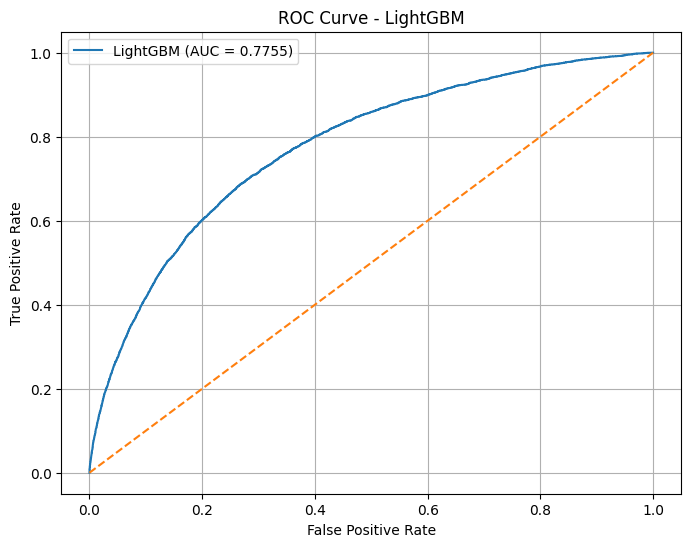

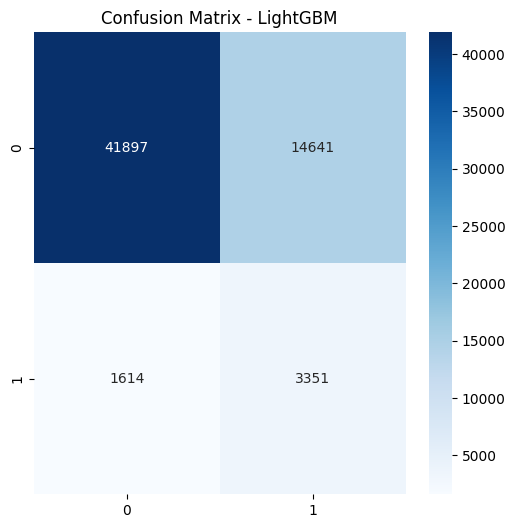

In [29]:

# 2. Train-Test Split (100% data used, no sampling)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 3. Handle Class Imbalance
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance Ratio: {ratio:.2f}")


# 4. Train SINGLE Model (LightGBM only)
from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42
)

final_model.fit(X_train, y_train)


# 5. Predictions
probs = final_model.predict_proba(X_val)[:, 1]
preds = final_model.predict(X_val)


# 6. Evaluation
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

print("\nROC-AUC:", roc_auc_score(y_val, probs))
print("\nClassification Report:\n", classification_report(y_val, preds))


# 7. ROC Curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_val, probs):.4f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.grid()
plt.show()


# 8. Confusion Matrix
import seaborn as sns

cm = confusion_matrix(y_val, preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM")
plt.show()



In [30]:
import joblib

joblib.dump(final_model, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [31]:
import os

print(os.listdir("/kaggle/working/"))

['final_master_dataset.csv', '.virtual_documents', 'lightgbm_model.pkl']


## ## Final Model Evaluation (LightGBM)

The final LightGBM model was evaluated on the validation set containing 307,511 samples with 202 features. The dataset is significantly imbalanced, with an imbalance ratio of approximately 11.39:1, meaning default cases (positive class) are much rarer than non-default cases.

The model achieved a ROC-AUC score of 0.775, indicating strong discriminatory ability between defaulters and non-defaulters. This confirms that the model is effective in ranking high-risk customers higher than low-risk ones.

## Classification Report Analysis

Although overall accuracy is 0.74, accuracy is not a reliable metric due to class imbalance. Therefore, precision, recall, and F1-score provide more meaningful insights:

Class 0 (Non-defaulters):
High precision (0.96) indicates reliable identification of good customers.
Moderate recall (0.74) shows some non-defaulters are misclassified.
Class 1 (Defaulters):
Precision is low (0.19), meaning many predicted defaulters are false alarms.
Recall is high (0.67), indicating the model successfully captures a majority of actual defaulters.
## Key Insight

The model prioritizes recall for the minority class (defaulters), which is desirable in credit risk scenarios because missing a defaulter is more costly than incorrectly flagging a safe customer.

## ## Conclusion

The LightGBM model demonstrates strong performance with a ROC-AUC of 0.775 and good recall for the minority class, making it suitable for credit default prediction tasks. Despite class imbalance challenges, the model effectively identifies high-risk applicants, supporting its use for deployment in real-world credit risk systems.